# Learning Trajectories: Do Players Evolve From Role-Tracking to Strategic Reasoning?

## Motivation
The individual model fitting experiment showed that ~45% of players are best described by
Bayesian-Belief (role-tracking) and ~33% by Random Walk (habit). But this assigns one model
per player across ALL their rounds. In reality, players might **learn** over time:

- **Layer 1 (Trait-based)**: Early on, just follow your stats. High STR -> Fighter.
- **Layer 2 (Role-tracking)**: After some experience, start observing teammates and inferring roles.
- **Layer 3 (Strategic)**: Eventually, reason about game state and pick the highest-value role.

## Research Questions
1. Does the best-fitting model for a player **change** across early vs. late rounds?
2. Is there a common trajectory (e.g., Optimal -> Bayesian-Belief -> Bayesian-Value)?
3. Do some players learn faster than others? Does stat profile predict learning speed?

## Approach
1. **Sliding window log-likelihood**: For each player, compute per-model log-likelihood
   in overlapping windows (e.g., rounds 1-3, 2-4, 3-5) to track model fit over time.
2. **Per-round model posterior**: Compute P(model | round data) for each player at each round,
   showing how the best-fitting model evolves.
3. **Transition analysis**: Count how often players transition between model categories
   (e.g., Random Walk -> Bayesian-Belief -> Bayesian-Value).
4. **Visualize trajectories**: Plot per-player model posterior evolution over rounds.
5. **Predictors of learning**: Do stat profiles, early-round win rates, or inference accuracy
   predict who transitions to more sophisticated models?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

from shared import EXPORTS_DIR, DATA_ROOT
from shared.constants import (
    F, T, M,
    ROLE_NAMES, ROLE_SHORT, ROLE_COLORS,
    ALL_ROLE_COMBOS, TURNS_PER_STAGE,
)
from shared.inference import (
    utility_based_prior, bayesian_update, action_prob, preferred_action, game_step,
    softmax_role_dist, combo_marginal,
    ATTACK, DEFEND, HEAL,
)
from shared.evaluation import (
    run_predictions, compute_pearson, compute_log_likelihood, extract_metrics,
)
from shared.data_loading import load_all_exports, to_dataframe
from shared.env_loading import make_env_loader

print("Imports OK")

Imports OK


## Step 1: Load Data

Same data loading as individual_model_fitting. We need team-round records with env configs,
plus participant ID mapping. Crucially, we need to preserve **round ordering** per player.

In [2]:
# Load per-player records (human rounds only, no dropout games)
DATA_DIRS = [
    EXPORTS_DIR / 'bayesian-role-specialization-2026-03-06-09-54-19',
    EXPORTS_DIR / 'bayesian-role-specialization-2026-03-18-15-47-09',
]
player_records = load_all_exports(data_dirs=DATA_DIRS, include_bot_rounds=False, include_dropout_games=False)
df = to_dataframe(player_records)
print(f"\n{len(df)} player-rounds, {df['participant_id'].nunique()} unique participants")
print(f"Games: {df['game_id'].nunique()}")
print(f"Round types: {df['round_type'].value_counts().to_dict()}")

# Build team-round records from per-player data
env_loader = make_env_loader()

team_records = []
grouped = df.groupby(['game_id', 'round_number'])

for (game_id, round_num), group in grouped:
    if len(group) != 3:
        print(f"WARNING: {game_id} R{round_num} has {len(group)} players, skipping")
        continue
    
    group = group.sort_values('player_id')
    players = group.to_dict('records')
    participant_ids = [p['participant_id'] for p in players]
    
    n_stages = min(p['n_stages'] for p in players)
    stage_roles = []
    for s in range(n_stages):
        combo = ''.join(ROLE_SHORT[players[pos]['role_idxs'][s]] for pos in range(3))
        stage_roles.append(combo)
    
    if not stage_roles:
        continue
    
    config = players[0]['config']
    optimal_roles_idx = config.get('optimalRoles', [])
    role_combo = ''.join(ROLE_SHORT[ri] for ri in optimal_roles_idx)
    stat_profile = players[0]['stat_profile_id']
    lds = [int(c) for c in players[0]['enemy_intent_sequence']]
    
    env_config = env_loader(role_combo=role_combo)
    
    team_records.append({
        'game_id': game_id,
        'round_number': round_num,
        'env_id': f"{stat_profile}_{role_combo}",
        'stat_profile': stat_profile,
        'optimal_roles': role_combo,
        'lds': lds,
        'stage_roles': stage_roles,
        'env_config': env_config,
        'participant_ids': participant_ids,
    })

print(f"\nBuilt {len(team_records)} team-rounds")

# Check participant coverage
all_pids = set()
pid_stage_counts = defaultdict(int)
for rec in team_records:
    for pos in range(3):
        pid = rec['participant_ids'][pos]
        all_pids.add(pid)
        pid_stage_counts[pid] += len(rec['stage_roles'])
print(f"Unique participants: {len(all_pids)}")
print(f"Stages per participant: mean={np.mean(list(pid_stage_counts.values())):.1f}, "
      f"range=[{min(pid_stage_counts.values())}, {max(pid_stage_counts.values())}]")


Loaded bayesian-role-specialization-2026-03-06-09-54-19: 54 player-rounds
Loaded bayesian-role-specialization-2026-03-18-15-47-09: 144 player-rounds
Total: 198 player-rounds from 2 exports

198 player-rounds, 33 unique participants
Games: 11
Round types: {'human': 198}

Built 66 team-rounds
Unique participants: 33
Stages per participant: mean=21.3, range=[19, 25]


## Step 2: Define Models

Same 5 models as individual_model_fitting, same parameters. Copy them directly.

In [3]:
from shared.constants import ROLE_CHAR_TO_IDX

def marginals_from_combo_dist(combo_dist):
    """Extract per-player marginals from a combo distribution."""
    marginals = [np.zeros(3) for _ in range(3)]
    for combo, prob in combo_dist.items():
        for i, c in enumerate(combo):
            marginals[i][ROLE_CHAR_TO_IDX[c]] += prob
    return marginals


# --- Model 1: Random ---
def model_random(record):
    uniform = np.ones(3) / 3.0
    return [[uniform.copy() for _ in range(3)] for _ in record['stage_roles']]


# --- Model 2: Random Walk (ε=0.38) ---
def make_model_random_walk(eps=0.38):
    def model(record):
        stage_marginals = []
        for s, combo in enumerate(record['stage_roles']):
            if s == 0:
                stage_marginals.append([np.ones(3) / 3.0 for _ in range(3)])
            else:
                prev_combo = record['stage_roles'][s - 1]
                player_margs = []
                for i in range(3):
                    marg = np.full(3, eps / 2.0)
                    prev_role_idx = ROLE_CHAR_TO_IDX[prev_combo[i]]
                    marg[prev_role_idx] = 1.0 - eps
                    player_margs.append(marg)
                stage_marginals.append(player_margs)
        return stage_marginals
    return model


# --- Model 3: Optimal ---
def model_optimal(record):
    env = record['env_config']
    values = env['values']
    lds = record['lds']
    team_max_hp = int(env['team_max_hp'])
    enemy_max_hp = int(env['enemy_max_hp'])
    
    stage_marginals = []
    for s in range(len(record['stage_roles'])):
        turn_idx = s * TURNS_PER_STAGE
        intent = lds[turn_idx] if turn_idx < len(lds) else 0
        thp = min(team_max_hp, values.shape[2] - 1)
        ehp = min(enemy_max_hp, values.shape[3] - 1)
        
        vals = []
        for combo in ALL_ROLE_COMBOS:
            idx = ROLE_CHAR_TO_IDX[combo[0]] * 9 + ROLE_CHAR_TO_IDX[combo[1]] * 3 + ROLE_CHAR_TO_IDX[combo[2]]
            vals.append(float(values[idx, intent, thp, ehp]))
        max_val = max(vals)
        
        combo_dist = {}
        optimal_combos = [c for c, v in zip(ALL_ROLE_COMBOS, vals) if abs(v - max_val) < 1e-8]
        for c in ALL_ROLE_COMBOS:
            combo_dist[c] = (1.0 / len(optimal_combos)) if c in optimal_combos else 0.0
        
        stage_marginals.append(marginals_from_combo_dist(combo_dist))
    return stage_marginals


# --- Model 4: Bayesian-Value (teacher-forced) ---
def make_model_bayesian_value(tau_prior=5.6, tau_softmax=0.1, epsilon=0.2):
    def model(record):
        env = record['env_config']
        values = env['values']
        player_stats = env['player_stats']
        boss_damage = env['boss_damage']
        team_max_hp, enemy_max_hp = env['team_max_hp'], env['enemy_max_hp']
        
        team_hp, enemy_hp = float(team_max_hp), float(enemy_max_hp)
        prior = utility_based_prior(player_stats, tau=tau_prior)
        stage_marginals = []
        turn_idx = 0
        
        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0:
                break
            
            intent = record['lds'][turn_idx]
            thp = int(min(max(0, team_hp), team_max_hp))
            ehp = int(min(max(0, enemy_hp), enemy_max_hp))
            
            per_agent = [softmax_role_dist(i, intent, thp, ehp, prior, values, tau_softmax) for i in range(3)]
            stage_marginals.append(per_agent)
            
            human_roles = [ROLE_CHAR_TO_IDX[c] for c in human_combo]
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0:
                    break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(human_roles[i], intent, team_hp, team_max_hp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, team_hp, team_max_hp, epsilon)
                team_hp, enemy_hp = game_step(intent, team_hp, enemy_hp, actions, player_stats, boss_damage, team_max_hp)
                turn_idx += 1
        
        return stage_marginals
    return model


# --- Model 5: Bayesian-Belief (teacher-forced) ---
def make_model_bayesian_belief(tau_prior=2.0, epsilon=0.5):
    def model(record):
        env = record['env_config']
        player_stats = env['player_stats']
        boss_damage = env['boss_damage']
        team_max_hp, enemy_max_hp = env['team_max_hp'], env['enemy_max_hp']
        
        team_hp, enemy_hp = float(team_max_hp), float(enemy_max_hp)
        prior = utility_based_prior(player_stats, tau=tau_prior)
        stage_marginals = []
        turn_idx = 0
        
        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0:
                break
            
            per_agent = []
            for i in range(3):
                marg = np.sum(prior, axis=tuple(j for j in range(3) if j != i))
                total = marg.sum()
                per_agent.append(marg / total if total > 0 else np.ones(3) / 3)
            stage_marginals.append(per_agent)
            
            human_roles = [ROLE_CHAR_TO_IDX[c] for c in human_combo]
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0:
                    break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(human_roles[i], intent, team_hp, team_max_hp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, team_hp, team_max_hp, epsilon)
                team_hp, enemy_hp = game_step(intent, team_hp, enemy_hp, actions, player_stats, boss_damage, team_max_hp)
                turn_idx += 1
        
        return stage_marginals
    return model


# Instantiate all models



# --- Model 6: Bayesian Walk (teacher-forced) ---
def make_model_bayesian_walk(tau_prior=5.71, tau_softmax=6.37, epsilon=0.20, epsilon_switch=0.35):
    def model(record):
        env = record['env_config']
        values = env['values']
        player_stats = env['player_stats']
        boss_damage = env['boss_damage']
        team_max_hp, enemy_max_hp = env['team_max_hp'], env['enemy_max_hp']

        team_hp, enemy_hp = float(team_max_hp), float(enemy_max_hp)
        prior = utility_based_prior(player_stats, tau=tau_prior)
        stage_marginals = []
        turn_idx = 0
        prev_roles = None

        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0:
                break
            intent = record['lds'][turn_idx]
            thp = int(min(max(0, team_hp), team_max_hp))
            ehp = int(min(max(0, enemy_hp), enemy_max_hp))

            switch_dist = [softmax_role_dist(i, intent, thp, ehp, prior, values, tau_softmax) for i in range(3)]
            per_agent = []
            for i in range(3):
                if prev_roles is None:
                    per_agent.append(switch_dist[i])
                else:
                    stick = np.zeros(3)
                    stick[prev_roles[i]] = 1.0
                    mixed = (1.0 - epsilon_switch) * stick + epsilon_switch * switch_dist[i]
                    per_agent.append(mixed)
            stage_marginals.append(per_agent)

            human_roles = [ROLE_CHAR_TO_IDX[c] for c in human_combo]
            prev_roles = human_roles
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0:
                    break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(human_roles[i], intent, team_hp, team_max_hp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, team_hp, team_max_hp, epsilon)
                team_hp, enemy_hp = game_step(intent, team_hp, enemy_hp, actions, player_stats, boss_damage, team_max_hp)
                turn_idx += 1
        return stage_marginals
    return model


# --- Model 7: Bayesian Threshold (teacher-forced) ---
def expected_values_per_role(agent_i, intent, team_hp, enemy_hp, prior, values):
    other_agents = [a for a in range(3) if a != agent_i]
    other_probs = np.sum(prior, axis=agent_i)
    total = other_probs.sum()
    other_probs = other_probs / total if total > 0 else np.ones((3, 3)) / 9.0
    ev = np.zeros(3)
    for r_i in range(3):
        for r_j in range(3):
            for r_k in range(3):
                roles = [0, 0, 0]
                roles[agent_i] = r_i
                roles[other_agents[0]] = r_j
                roles[other_agents[1]] = r_k
                flat_idx = roles[0] * 9 + roles[1] * 3 + roles[2]
                ev[r_i] += other_probs[r_j, r_k] * float(values[flat_idx, intent, team_hp, enemy_hp])
    return ev


def threshold_role_dist(agent_i, intent, team_hp, enemy_hp, prior, values, current_role, delta, tau):
    ev = expected_values_per_role(agent_i, intent, team_hp, enemy_hp, prior, values)
    current_val = ev[current_role]
    candidates = [r for r in range(3) if r != current_role and (ev[r] - current_val) > delta]
    if not candidates:
        dist = np.zeros(3)
        dist[current_role] = 1.0
        return dist
    candidate_vals = np.array([ev[r] for r in candidates])
    scaled = candidate_vals / tau
    scaled -= scaled.max()
    exp_vals = np.exp(scaled)
    probs = exp_vals / exp_vals.sum()
    dist = np.zeros(3)
    for i, r in enumerate(candidates):
        dist[r] = probs[i]
    return dist


def make_model_bayesian_thresh(tau_prior=5.63, tau_softmax=3.86, epsilon=0.17, delta=3.33):
    def model(record):
        env = record['env_config']
        values = env['values']
        player_stats = env['player_stats']
        boss_damage = env['boss_damage']
        team_max_hp, enemy_max_hp = env['team_max_hp'], env['enemy_max_hp']

        team_hp, enemy_hp = float(team_max_hp), float(enemy_max_hp)
        prior = utility_based_prior(player_stats, tau=tau_prior)
        stage_marginals = []
        turn_idx = 0
        prev_roles = None

        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0:
                break
            intent = record['lds'][turn_idx]
            thp = int(min(max(0, team_hp), team_max_hp))
            ehp = int(min(max(0, enemy_hp), enemy_max_hp))

            per_agent = []
            for i in range(3):
                if prev_roles is None:
                    per_agent.append(softmax_role_dist(i, intent, thp, ehp, prior, values, tau_softmax))
                else:
                    per_agent.append(threshold_role_dist(
                        i, intent, thp, ehp, prior, values,
                        current_role=prev_roles[i], delta=delta, tau=tau_softmax))
            stage_marginals.append(per_agent)

            human_roles = [ROLE_CHAR_TO_IDX[c] for c in human_combo]
            prev_roles = human_roles
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0:
                    break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(human_roles[i], intent, team_hp, team_max_hp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, team_hp, team_max_hp, epsilon)
                team_hp, enemy_hp = game_step(intent, team_hp, enemy_hp, actions, player_stats, boss_damage, team_max_hp)
                turn_idx += 1
        return stage_marginals
    return model


MODELS = {
    'Random': model_random,
    'Random Walk': make_model_random_walk(eps=0.38),
    'Optimal': model_optimal,
    'Bayesian-Value': make_model_bayesian_value(tau_prior=5.6, tau_softmax=0.1, epsilon=0.2),
    'Bayesian-Belief': make_model_bayesian_belief(tau_prior=2.0, epsilon=0.5),
    'Bayesian Walk': make_model_bayesian_walk(tau_prior=5.71, tau_softmax=6.37, epsilon=0.20, epsilon_switch=0.35),
    'Bayesian Threshold': make_model_bayesian_thresh(tau_prior=5.63, tau_softmax=3.86, epsilon=0.17, delta=3.33),
}

LAPSE_RATE = 0.05
UNIFORM = np.ones(3) / 3.0
model_names = list(MODELS.keys())

def apply_lapse(marginal, lapse=LAPSE_RATE):
    return (1.0 - lapse) * marginal + lapse * UNIFORM

# Sanity check
test_rec = team_records[0]
for name, fn in MODELS.items():
    margs = fn(test_rec)
    print(f"{name}: {len(margs)} stages, player 0 stage 0 = {margs[0][0].round(3)}")


Random: 3 stages, player 0 stage 0 = [0.333 0.333 0.333]
Random Walk: 3 stages, player 0 stage 0 = [0.333 0.333 0.333]
Optimal: 3 stages, player 0 stage 0 = [1. 0. 0.]
Bayesian-Value: 3 stages, player 0 stage 0 = [1. 0. 0.]
Bayesian-Belief: 3 stages, player 0 stage 0 = [0.691 0.154 0.154]
Bayesian Walk: 3 stages, player 0 stage 0 = [0.6   0.292 0.108]
Bayesian Threshold: 3 stages, player 0 stage 0 = [0.734 0.223 0.043]


## Step 3: Per-Round Log-Likelihood

Instead of summing log-likelihood across ALL rounds for a player, compute it **per round**.
Each round has multiple stages (typically 3-5), so we get a log-likelihood per model per round per player.
This gives us a time series of model fit.

In [4]:
# Per-round log-likelihood: for each player in each round, sum log P(chosen_role) across stages

# First, sort team_records by (game_id, round_number) to ensure temporal order
team_records.sort(key=lambda r: (r['game_id'], r['round_number']))

# Track round_order per participant (sequential index of rounds played)
pid_round_counter = defaultdict(int)

per_round_rows = []

for rec in team_records:
    model_outputs = {name: fn(rec) for name, fn in MODELS.items()}
    
    for pos in range(3):
        pid = rec['participant_ids'][pos]
        pid_round_counter[pid] += 1
        round_order = pid_round_counter[pid]
        
        row = {
            'participant_id': pid,
            'game_id': rec['game_id'],
            'round_number': rec['round_number'],
            'round_order': round_order,
            'n_stages': len(rec['stage_roles']),
            'stat_profile': rec['stat_profile'],
            'optimal_roles': rec['optimal_roles'],
        }
        
        for name in model_names:
            ll = 0.0
            margs = model_outputs[name]
            for s, human_combo in enumerate(rec['stage_roles']):
                actual_role_idx = ROLE_CHAR_TO_IDX[human_combo[pos]]
                if s < len(margs):
                    prob = apply_lapse(margs[s][pos])[actual_role_idx]
                else:
                    prob = 1.0 / 3.0
                ll += np.log(max(prob, 1e-20))
            row[f'll_{name}'] = ll
        
        per_round_rows.append(row)

per_round_df = pd.DataFrame(per_round_rows)

print(f"Per-round LL: {len(per_round_df)} rows (player-rounds)")
print(f"Rounds per player: {per_round_df.groupby('participant_id')['round_order'].max().describe()}")
print(f"\nSample:")
print(per_round_df[['participant_id', 'round_order', 'n_stages'] + [f'll_{n}' for n in model_names]].head(8).to_string(float_format='{:.2f}'.format))


Per-round LL: 198 rows (player-rounds)


Rounds per player: count    33.0
mean      6.0
std       0.0
min       6.0
25%       6.0
50%       6.0
75%       6.0
max       6.0
Name: round_order, dtype: float64

Sample:
               participant_id  round_order  n_stages  ll_Random  ll_Random Walk  ll_Optimal  ll_Bayesian-Value  ll_Bayesian-Belief  ll_Bayesian Walk  ll_Bayesian Threshold
0  01KK14VYMQG76JJB7WRNQAG8JS            1         3      -3.30           -4.35       -4.16              -4.16               -3.13             -5.96                  -5.04
1  01KK151DEMDQP6895Y4Q9YRAMC            1         3      -3.30           -4.35       -6.29              -8.22               -3.90             -4.95                  -5.40
2  01KK152ABN78TH8X8TDYYVA3QZ            1         3      -3.30           -3.22       -2.63              -8.22               -2.82             -3.33                  -9.46
3  01KK14VYMQG76JJB7WRNQAG8JS            2         5      -5.49           -7.59      -12.35             -12.35               -7.71        

## Step 4: Per-Round Model Posterior

For each player at each round, compute P(model | this round's data).
This gives a time series of which model best explains the player at each point.

In [5]:
# Per-round model posterior: P(model | this round's data)
ll_cols = [f'll_{n}' for n in model_names]

posterior_rows = []
for _, row in per_round_df.iterrows():
    lls = np.array([row[c] for c in ll_cols])
    log_post = lls - lls.max()
    post = np.exp(log_post)
    post = post / post.sum()
    
    prow = {
        'participant_id': row['participant_id'],
        'round_order': row['round_order'],
        'round_number': row['round_number'],
        'game_id': row['game_id'],
        'stat_profile': row['stat_profile'],
        'n_stages': row['n_stages'],
    }
    for i, name in enumerate(model_names):
        prow[f'post_{name}'] = post[i]
    prow['dominant_model'] = model_names[np.argmax(post)]
    posterior_rows.append(prow)

post_df = pd.DataFrame(posterior_rows)

print("Per-round posteriors:")
print(post_df.groupby('round_order')['dominant_model'].value_counts().unstack(fill_value=0))
print(f"\nOverall dominant model distribution:")
print(post_df['dominant_model'].value_counts())


Per-round posteriors:
dominant_model  Bayesian Threshold  Bayesian Walk  Bayesian-Belief  \
round_order                                                          
1                                4              0                4   
2                                5              1                5   
3                                6              3                5   
4                                7              1                3   
5                                9              4                4   
6                                6              2                3   

dominant_model  Bayesian-Value  Optimal  Random  Random Walk  
round_order                                                   
1                            1       15       6            3  
2                            2        9       7            4  
3                            3        4       5            7  
4                            4        9       7            2  
5                            5        5

## Step 4b: Sliding Window Posterior (smoothed)

Single-round posteriors are noisy (few stages per round). Use a sliding window of
2-3 rounds to get smoother trajectories. Sum log-likelihoods within the window
before computing the posterior.

In [6]:
# Sliding window posterior: sum LL across window of consecutive rounds, then compute posterior

def compute_sliding_window_posteriors(per_round_df, model_names, window_size=2):
    """Compute sliding window posteriors for each player."""
    ll_cols = [f'll_{n}' for n in model_names]
    rows = []
    
    for pid, grp in per_round_df.groupby('participant_id'):
        grp = grp.sort_values('round_order')
        n_rounds = len(grp)
        
        for start in range(n_rounds - window_size + 1):
            window = grp.iloc[start:start + window_size]
            
            # Sum log-likelihoods across window
            summed_lls = np.array([window[c].sum() for c in ll_cols])
            log_post = summed_lls - summed_lls.max()
            post = np.exp(log_post)
            post = post / post.sum()
            
            # Use end of window as the round_order label
            window_center = window['round_order'].iloc[-1]
            
            row = {
                'participant_id': pid,
                'window_end': int(window_center),
                'window_start': int(window['round_order'].iloc[0]),
                'stat_profile': window['stat_profile'].iloc[0],
            }
            for i, name in enumerate(model_names):
                row[f'post_{name}'] = post[i]
            row['dominant_model'] = model_names[np.argmax(post)]
            rows.append(row)
    
    return pd.DataFrame(rows)

sw2_df = compute_sliding_window_posteriors(per_round_df, model_names, window_size=2)
sw3_df = compute_sliding_window_posteriors(per_round_df, model_names, window_size=3)

print(f"Window=2: {len(sw2_df)} rows ({sw2_df['participant_id'].nunique()} players x {sw2_df.groupby('participant_id').size().iloc[0]} windows)")
print(f"Window=3: {len(sw3_df)} rows ({sw3_df['participant_id'].nunique()} players x {sw3_df.groupby('participant_id').size().iloc[0]} windows)")

print(f"\nWindow=2 dominant model distribution:")
print(sw2_df['dominant_model'].value_counts())


Window=2: 165 rows (33 players x 5 windows)


Window=3: 132 rows (33 players x 4 windows)

Window=2 dominant model distribution:
dominant_model
Bayesian Threshold    36
Bayesian-Belief       30
Random Walk           29
Optimal               25
Random                20
Bayesian Walk         15
Bayesian-Value        10
Name: count, dtype: int64


## Step 5: Visualize Individual Trajectories

For each player, plot how their model posterior evolves over rounds.
This is the core visualization — it shows learning trajectories.

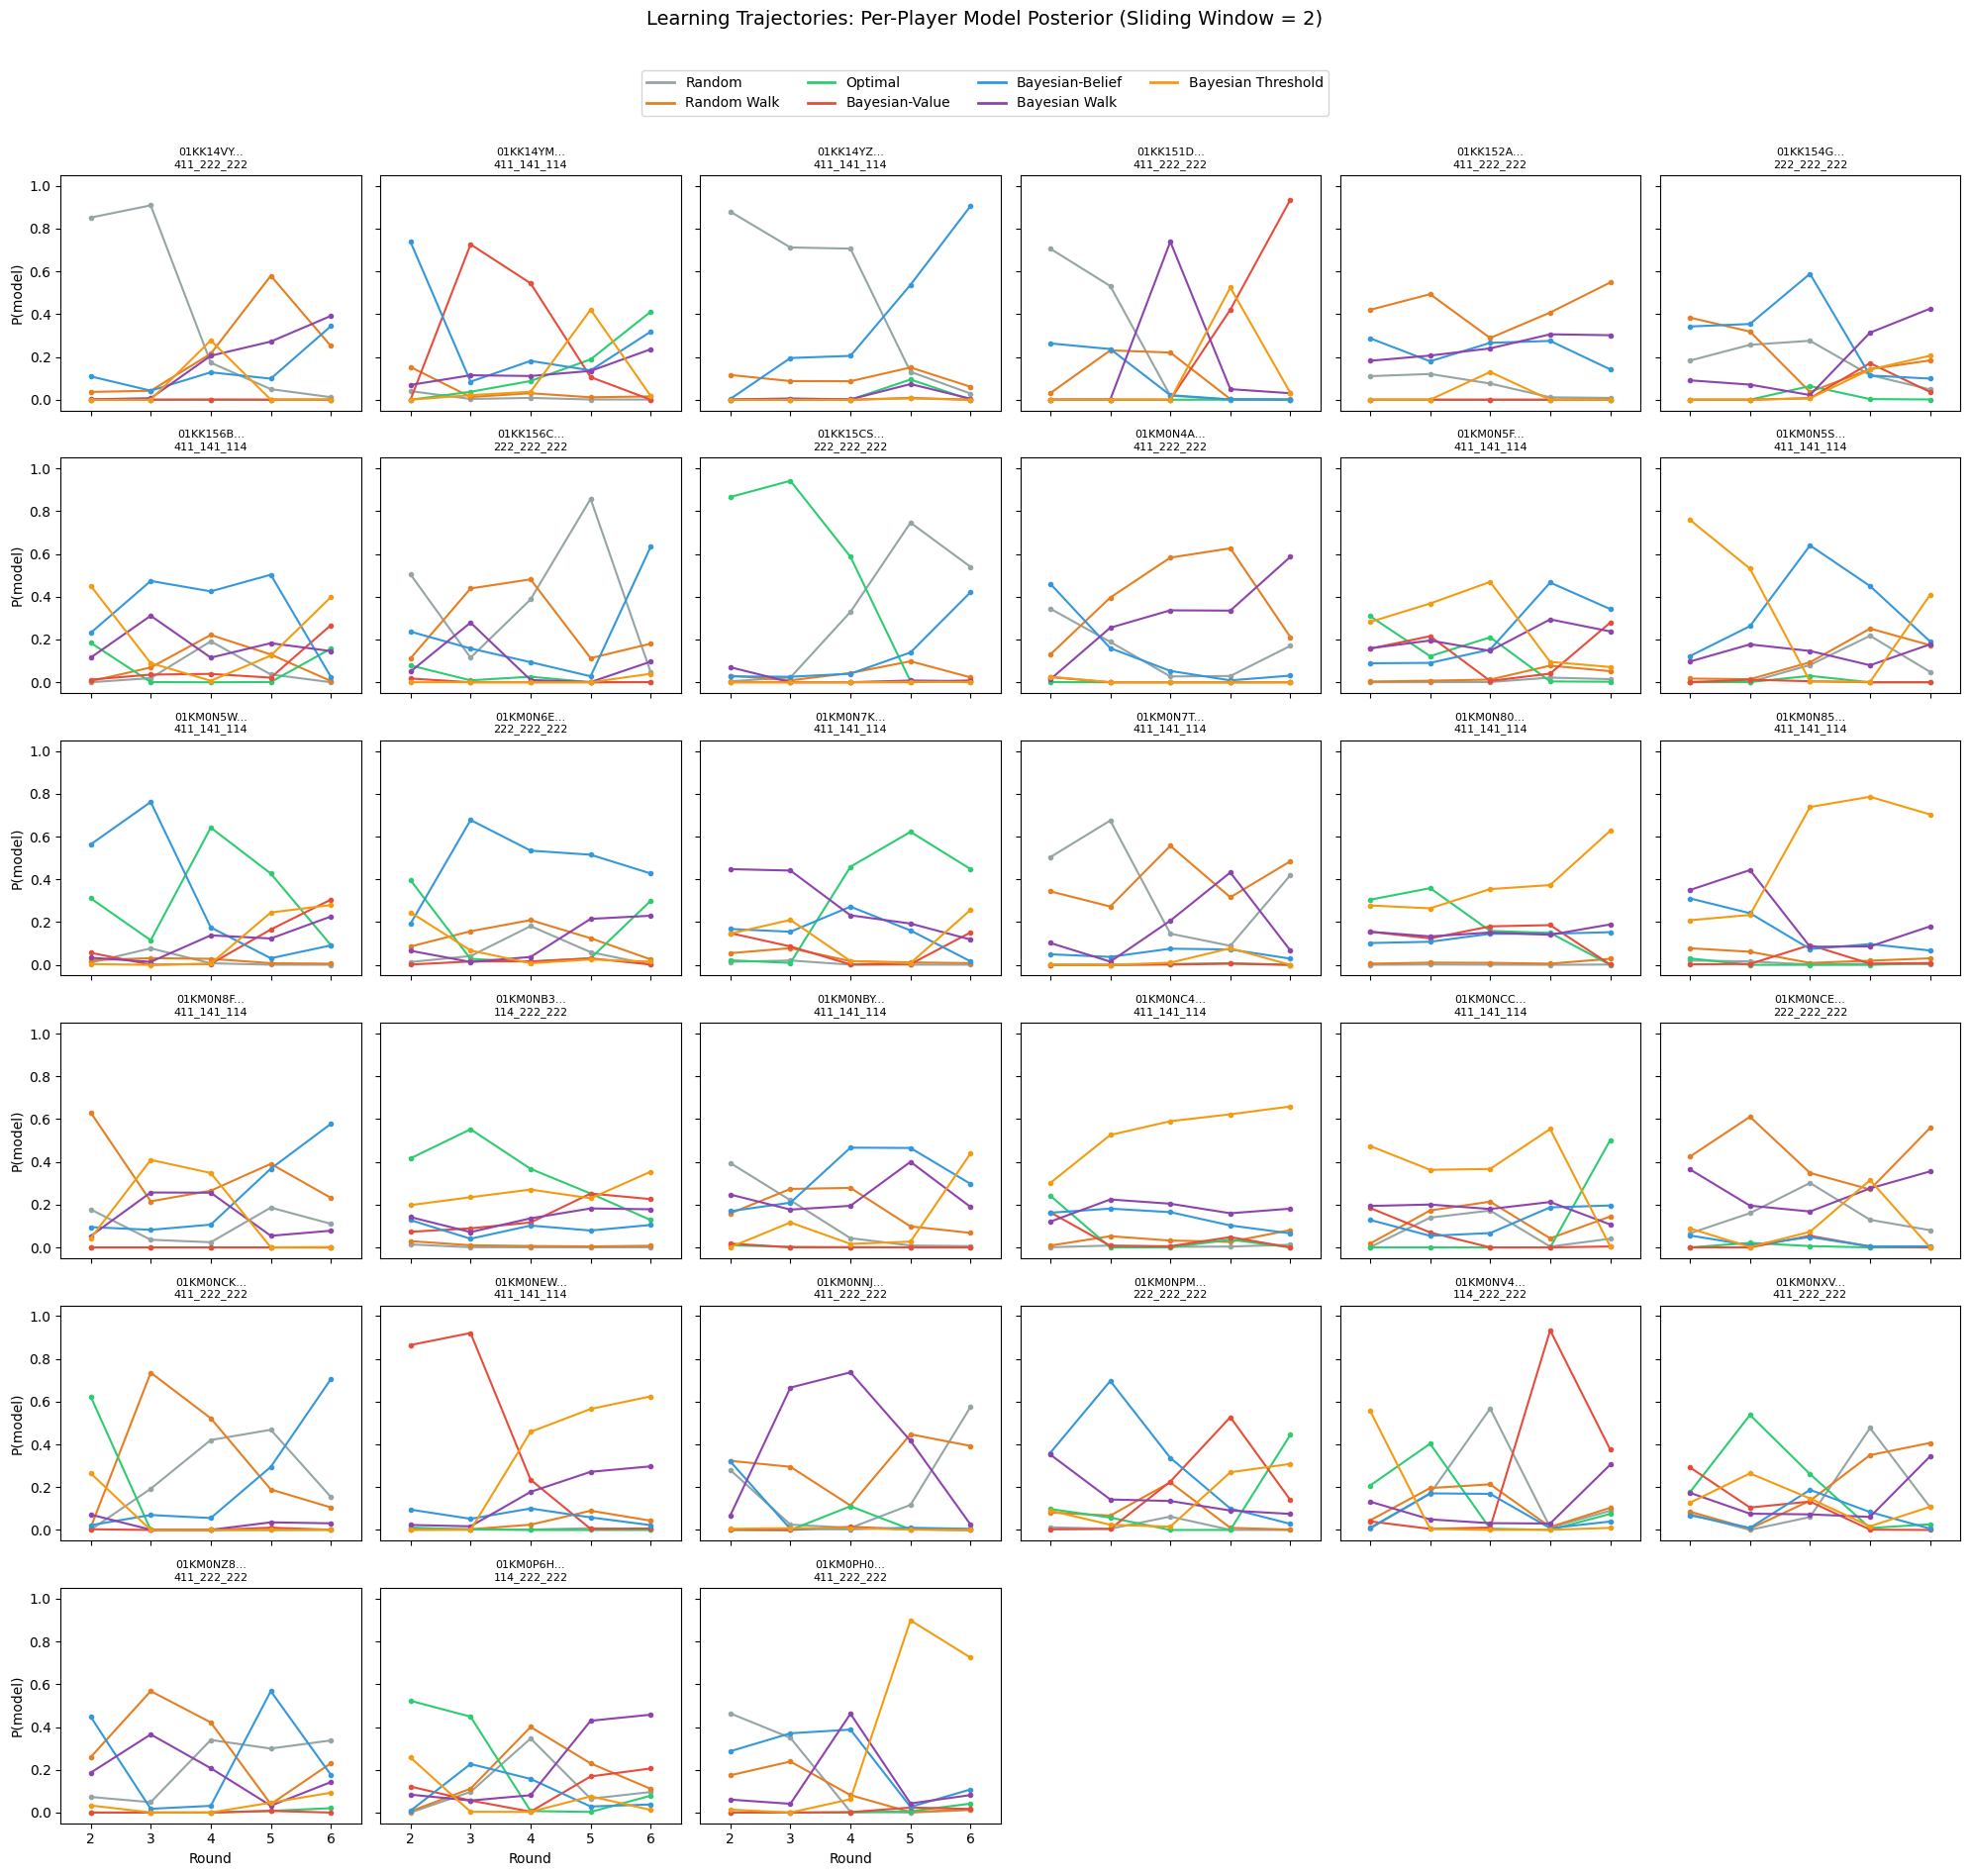

Saved individual_trajectories_w2.png


In [7]:
# Individual trajectory plots: small multiples grid, one subplot per player
# Using sliding window (w=2) posteriors

SAVE_DIR = Path('/Users/jolow/coding/bayesian-role-specialization/analysis/experiments/2026-03-29_learning_trajectories')

model_colors = {
    'Random': '#95a5a6',
    'Random Walk': '#e67e22',
    'Optimal': '#2ecc71',
    'Bayesian-Value': '#e74c3c',
    'Bayesian-Belief': '#3498db',
    'Bayesian Walk': '#8e44ad',
    'Bayesian Threshold': '#f39c12',
}

# Get sorted list of participants
pids_sorted = sorted(sw2_df['participant_id'].unique())
n_players = len(pids_sorted)
ncols = 6
nrows = int(np.ceil(n_players / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3), sharex=True, sharey=True)
axes_flat = axes.flatten()

post_cols = [f'post_{n}' for n in model_names]

for idx, pid in enumerate(pids_sorted):
    ax = axes_flat[idx]
    player_data = sw2_df[sw2_df['participant_id'] == pid].sort_values('window_end')
    stat_prof = player_data['stat_profile'].iloc[0]
    
    for name in model_names:
        ax.plot(player_data['window_end'], player_data[f'post_{name}'],
                color=model_colors[name], linewidth=1.5, marker='o', markersize=3,
                label=name if idx == 0 else None)
    
    ax.set_title(f'{pid[:8]}...\n{stat_prof}', fontsize=8)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(1.5, 6.5)
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Round')
    if idx % ncols == 0:
        ax.set_ylabel('P(model)')

# Hide empty subplots
for idx in range(n_players, len(axes_flat)):
    axes_flat[idx].set_visible(False)

# Single legend at top
handles = [plt.Line2D([0], [0], color=model_colors[n], linewidth=2, label=n) for n in model_names]
fig.legend(handles=handles, loc='upper center', ncol=4, fontsize=10, bbox_to_anchor=(0.5, 1.02))

fig.suptitle('Learning Trajectories: Per-Player Model Posterior (Sliding Window = 2)', 
             fontsize=14, y=1.05)
plt.tight_layout()
fig.savefig(SAVE_DIR / 'individual_trajectories_w2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved individual_trajectories_w2.png")


## Step 6: Aggregate Trajectory Analysis

Look for population-level patterns: does the average player shift toward more
sophisticated models over time?

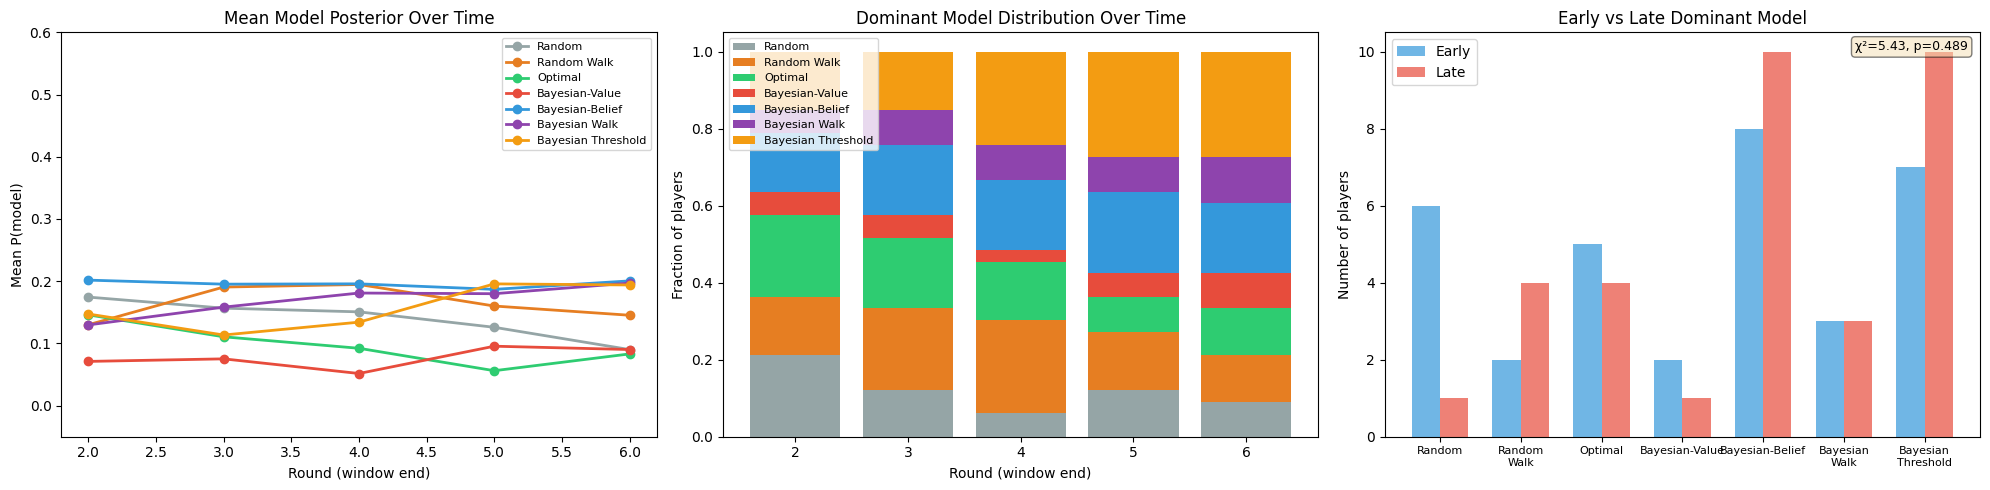


Chi-square test (early vs late dominant model): χ²=5.43, p=0.489, dof=6
Early: {'Random': np.int64(6), 'Random Walk': np.int64(2), 'Optimal': np.int64(5), 'Bayesian-Value': np.int64(2), 'Bayesian-Belief': np.int64(8), 'Bayesian Walk': np.int64(3), 'Bayesian Threshold': np.int64(7)}
Late:  {'Random': np.int64(1), 'Random Walk': np.int64(4), 'Optimal': np.int64(4), 'Bayesian-Value': np.int64(1), 'Bayesian-Belief': np.int64(10), 'Bayesian Walk': np.int64(3), 'Bayesian Threshold': np.int64(10)}


In [8]:
# Step 6: Aggregate Trajectory Analysis
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# --- 6a: Mean P(model) across all players at each round_order ---
ax = axes[0]
for name in model_names:
    means = sw2_df.groupby('window_end')[f'post_{name}'].mean()
    ax.plot(means.index, means.values, color=model_colors[name], linewidth=2, marker='o', label=name)
ax.set_xlabel('Round (window end)')
ax.set_ylabel('Mean P(model)')
ax.set_title('Mean Model Posterior Over Time')
ax.legend(fontsize=8)
ax.set_ylim(-0.05, 0.6)

# --- 6b: Dominant model frequency by round_order (stacked area) ---
ax = axes[1]
round_orders = sorted(sw2_df['window_end'].unique())
freq_data = {}
for ro in round_orders:
    sub = sw2_df[sw2_df['window_end'] == ro]
    counts = sub['dominant_model'].value_counts()
    total = len(sub)
    for name in model_names:
        if name not in freq_data:
            freq_data[name] = []
        freq_data[name].append(counts.get(name, 0) / total)

bottoms = np.zeros(len(round_orders))
for name in model_names:
    vals = np.array(freq_data[name])
    ax.bar(round_orders, vals, bottom=bottoms, color=model_colors[name], label=name, width=0.8)
    bottoms += vals
ax.set_xlabel('Round (window end)')
ax.set_ylabel('Fraction of players')
ax.set_title('Dominant Model Distribution Over Time')
ax.legend(fontsize=8, loc='upper left')

# --- 6c: Early vs Late split ---
ax = axes[2]
# Split each player's rounds in half
early_dom = []
late_dom = []
for pid in pids_sorted:
    player_data = sw2_df[sw2_df['participant_id'] == pid].sort_values('window_end')
    n = len(player_data)
    mid = n // 2
    early = player_data.iloc[:mid]
    late = player_data.iloc[mid:]
    
    # Dominant model in each half (most frequent)
    early_dom.append(early['dominant_model'].mode().iloc[0])
    late_dom.append(late['dominant_model'].mode().iloc[0])

# Count transitions
early_counts = pd.Series(early_dom).value_counts()
late_counts = pd.Series(late_dom).value_counts()

x = np.arange(len(model_names))
w = 0.35
early_vals = [early_counts.get(n, 0) for n in model_names]
late_vals = [late_counts.get(n, 0) for n in model_names]
bars1 = ax.bar(x - w/2, early_vals, w, label='Early', color='#3498db', alpha=0.7)
bars2 = ax.bar(x + w/2, late_vals, w, label='Late', color='#e74c3c', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels([n.replace(' ', '\n') for n in model_names], fontsize=8)
ax.set_ylabel('Number of players')
ax.set_title('Early vs Late Dominant Model')
ax.legend()

# Chi-square test
contingency = np.array([early_vals, late_vals])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
ax.text(0.98, 0.98, f'χ²={chi2:.2f}, p={p_val:.3f}', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
fig.savefig(SAVE_DIR / 'aggregate_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nChi-square test (early vs late dominant model): χ²={chi2:.2f}, p={p_val:.3f}, dof={dof}")
print(f"Early: {dict(zip(model_names, early_vals))}")
print(f"Late:  {dict(zip(model_names, late_vals))}")


## Step 7: Transition Analysis

Count transitions between dominant models across consecutive rounds.
Build a transition matrix.

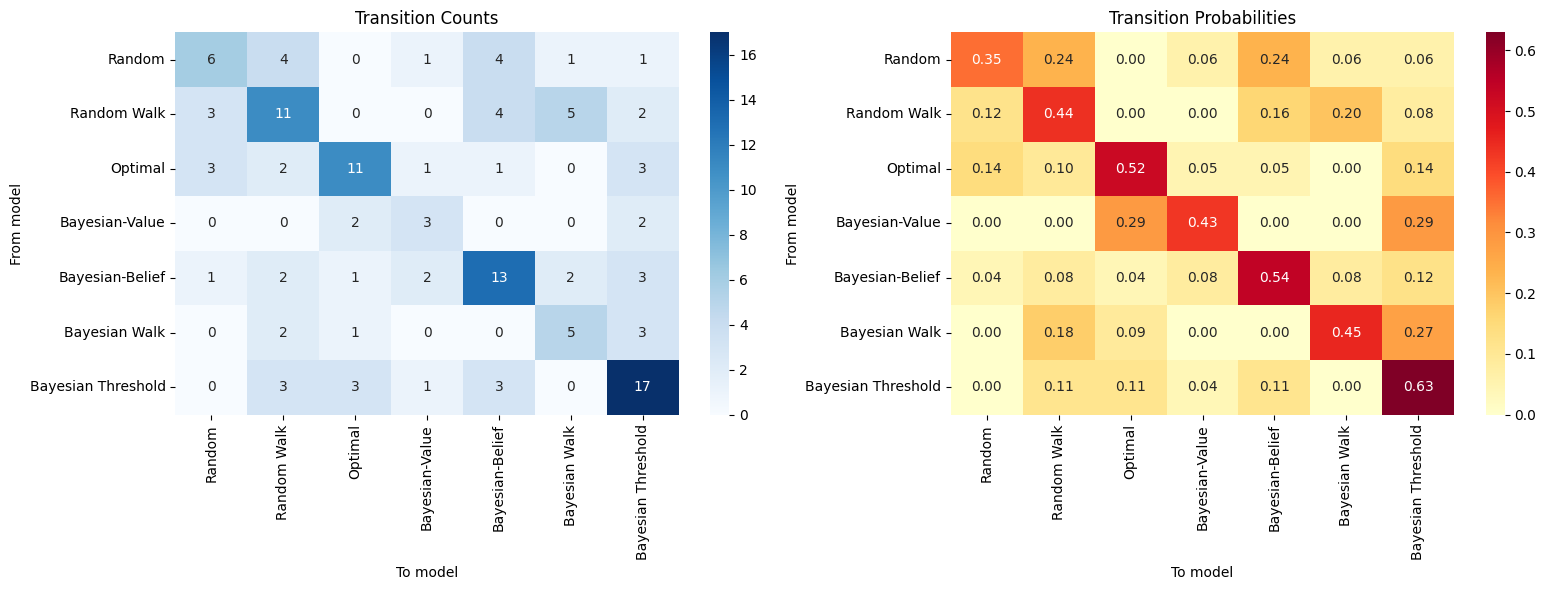


Simpler -> Complex transitions: 23
Complex -> Simpler transitions: 15
Ratio (S->C)/(C->S): 1.53


In [9]:
# Step 7: Transition Matrix
# Count (dominant_model[t], dominant_model[t+1]) transitions across consecutive windows

transitions = defaultdict(lambda: defaultdict(int))
for pid in pids_sorted:
    player_data = sw2_df[sw2_df['participant_id'] == pid].sort_values('window_end')
    dom_seq = player_data['dominant_model'].tolist()
    for t in range(len(dom_seq) - 1):
        transitions[dom_seq[t]][dom_seq[t+1]] += 1

# Build transition matrix
trans_matrix = np.zeros((len(model_names), len(model_names)))
for i, from_m in enumerate(model_names):
    for j, to_m in enumerate(model_names):
        trans_matrix[i, j] = transitions[from_m][to_m]

# Normalize rows
row_sums = trans_matrix.sum(axis=1, keepdims=True)
trans_prob = np.where(row_sums > 0, trans_matrix / row_sums, 0)

# Plot heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
ax = axes[0]
sns.heatmap(trans_matrix, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=model_names, yticklabels=model_names, ax=ax)
ax.set_xlabel('To model')
ax.set_ylabel('From model')
ax.set_title('Transition Counts')

# Probabilities
ax = axes[1]
sns.heatmap(trans_prob, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=model_names, yticklabels=model_names, ax=ax)
ax.set_xlabel('To model')
ax.set_ylabel('From model')
ax.set_title('Transition Probabilities')

plt.tight_layout()
fig.savefig(SAVE_DIR / 'transition_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Simpler -> Complex analysis
simpler = {'Random', 'Random Walk', 'Optimal'}
complex_ = {'Bayesian-Belief', 'Bayesian-Value', 'Bayesian Walk', 'Bayesian Threshold'}

simple_to_complex = 0
complex_to_simple = 0
for pid in pids_sorted:
    player_data = sw2_df[sw2_df['participant_id'] == pid].sort_values('window_end')
    dom_seq = player_data['dominant_model'].tolist()
    for t in range(len(dom_seq) - 1):
        if dom_seq[t] in simpler and dom_seq[t+1] in complex_:
            simple_to_complex += 1
        elif dom_seq[t] in complex_ and dom_seq[t+1] in simpler:
            complex_to_simple += 1

print(f"\nSimpler -> Complex transitions: {simple_to_complex}")
print(f"Complex -> Simpler transitions: {complex_to_simple}")
print(f"Ratio (S->C)/(C->S): {simple_to_complex/max(complex_to_simple,1):.2f}")


## Step 8: Predictors of Learning

What predicts whether a player transitions to more sophisticated models?

In [10]:
# Step 8: Predictors of Learning

# For each player compute:
# 1. learning_score = change in P(Bayesian-Belief) + P(Bayesian-Value) from first half to second half
# 2. stat_profile type (symmetric vs asymmetric)
# 3. early win rate
# 4. stat-optimal adherence

from shared.constants import SYMMETRIC_PROFILES

predictor_rows = []

for pid in pids_sorted:
    player_sw = sw2_df[sw2_df['participant_id'] == pid].sort_values('window_end')
    n = len(player_sw)
    mid = n // 2
    early = player_sw.iloc[:mid]
    late = player_sw.iloc[mid:]
    
    # Learning score: change in P(complex models)
    early_complex = (early['post_Bayesian-Belief'] + early['post_Bayesian-Value'] + early['post_Bayesian Walk'] + early['post_Bayesian Threshold']).mean()
    late_complex = (late['post_Bayesian-Belief'] + late['post_Bayesian-Value'] + late['post_Bayesian Walk'] + late['post_Bayesian Threshold']).mean()
    learning_score = late_complex - early_complex
    
    # Stat profile
    player_rounds = per_round_df[per_round_df['participant_id'] == pid]
    stat_prof = player_rounds['stat_profile'].iloc[0]
    is_symmetric = stat_prof in SYMMETRIC_PROFILES if hasattr(SYMMETRIC_PROFILES, '__contains__') else '222' in stat_prof
    
    # Early win rate (from team records)
    pid_team_recs = [(i, r) for i, r in enumerate(team_records) 
                     if pid in r['participant_ids']]
    n_recs = len(pid_team_recs)
    early_recs = pid_team_recs[:n_recs // 2]
    
    # We need outcome info - check if it's in the dataframe
    pid_df = df[df['participant_id'] == pid].sort_values('round_number')
    early_wins = pid_df.iloc[:len(pid_df)//2]['outcome'].apply(lambda x: 1 if x == 'WIN' else 0).mean() if 'outcome' in pid_df.columns else np.nan
    
    # Stat-optimal adherence
    optimal_count = 0
    total_stages = 0
    for _, row in pid_df.iterrows():
        opt_roles = row.get('optimal_roles', [])
        role_idxs = row.get('role_idxs', [])
        if opt_roles and role_idxs:
            # Player's position in the game
            pid_pos = row.get('player_id', 0)
            if isinstance(opt_roles, list) and pid_pos < len(opt_roles):
                for ri in role_idxs:
                    total_stages += 1
                    if ri == opt_roles[pid_pos]:
                        optimal_count += 1
    stat_opt_adherence = optimal_count / total_stages if total_stages > 0 else np.nan
    
    predictor_rows.append({
        'participant_id': pid,
        'stat_profile': stat_prof,
        'is_symmetric': is_symmetric,
        'learning_score': learning_score,
        'early_win_rate': early_wins,
        'stat_opt_adherence': stat_opt_adherence,
        'early_complex_prob': early_complex,
        'late_complex_prob': late_complex,
    })

pred_df = pd.DataFrame(predictor_rows)
print(f"Learning scores: mean={pred_df['learning_score'].mean():.3f}, std={pred_df['learning_score'].std():.3f}")
print(f"Range: [{pred_df['learning_score'].min():.3f}, {pred_df['learning_score'].max():.3f}]")
print(f"\nSymmetric profiles: {pred_df['is_symmetric'].sum()}, Asymmetric: {(~pred_df['is_symmetric']).sum()}")
print(pred_df[['participant_id', 'stat_profile', 'learning_score', 'early_win_rate', 'stat_opt_adherence']].to_string(float_format='{:.3f}'.format))


Learning scores: mean=0.088, std=0.245
Range: [-0.424, 0.668]

Symmetric profiles: 18, Asymmetric: 15
                participant_id stat_profile  learning_score  early_win_rate  stat_opt_adherence
0   01KK14VYMQG76JJB7WRNQAG8JS  411_222_222           0.493           0.333               0.520
1   01KK14YMHKVJNXZC5CBQ01234T  411_141_114          -0.129           0.667               0.762
2   01KK14YZGGKW3QSWB438DNTCY8  411_141_114           0.478           0.667               0.143
3   01KK151DEMDQP6895Y4Q9YRAMC  411_222_222           0.668           0.333               0.400
4   01KK152ABN78TH8X8TDYYVA3QZ  411_222_222           0.126           0.333               0.200
5   01KK154GTYND381DYD3WMWK0V7  222_222_222           0.281           1.000               0.522
6   01KK156BWNV8GZHEYKH36YWK8X  411_141_114          -0.108           0.667               0.714
7   01KK156CMNXC88GTTC061GMR9R  222_222_222          -0.069           1.000               0.565
8   01KK15CSZVJD5GPKEHMV7C1W9C  22

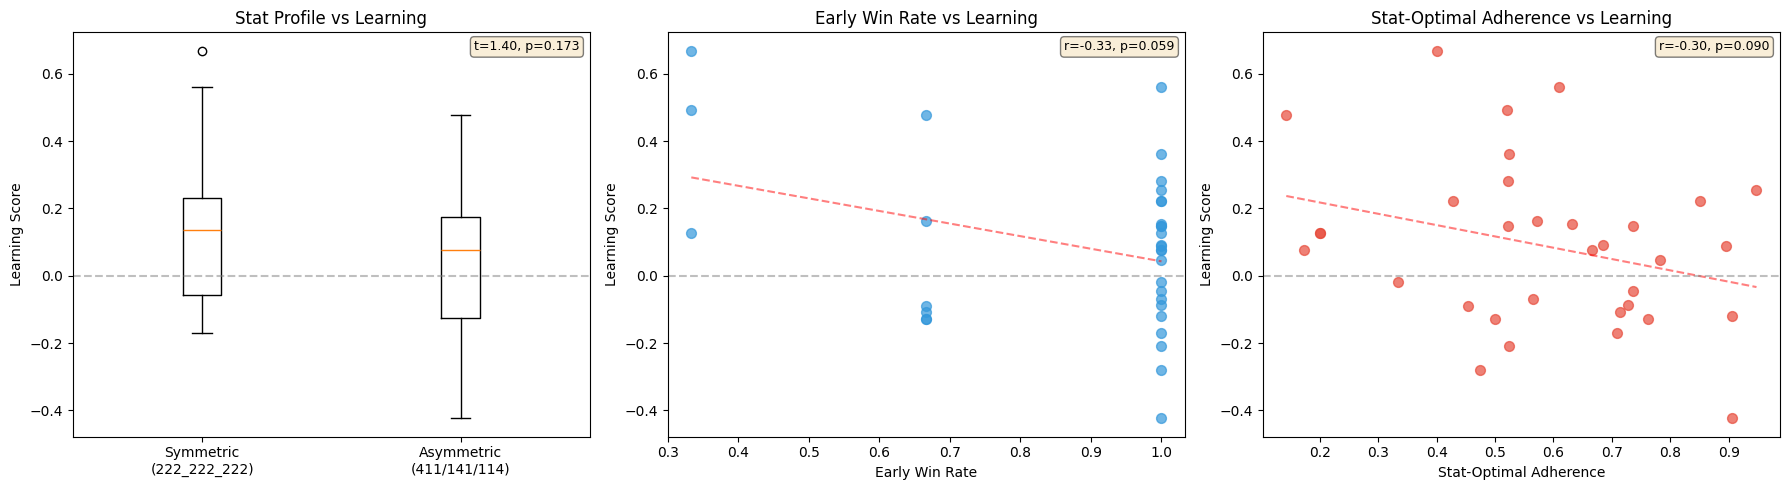


Summary:
  Symmetric vs Asymmetric learning: t=1.40, p=0.173
  Early win rate vs learning: r=-0.33, p=0.059
  Stat-optimal adherence vs learning: r=-0.30, p=0.090


In [11]:

# Fix the deprecation warning in boxplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Stat profile type vs learning score
ax = axes[0]
sym_scores = pred_df[pred_df['is_symmetric']]['learning_score']
asym_scores = pred_df[~pred_df['is_symmetric']]['learning_score']
ax.boxplot([sym_scores, asym_scores], tick_labels=['Symmetric\n(222_222_222)', 'Asymmetric\n(411/141/114)'])
ax.set_ylabel('Learning Score')
ax.set_title('Stat Profile vs Learning')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
t_stat, t_p = stats.ttest_ind(sym_scores, asym_scores)
ax.text(0.98, 0.98, f't={t_stat:.2f}, p={t_p:.3f}', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Early win rate vs learning score
ax = axes[1]
valid = pred_df.dropna(subset=['early_win_rate'])
ax.scatter(valid['early_win_rate'], valid['learning_score'], 
           c=[model_colors.get('Bayesian-Belief', '#3498db')], alpha=0.7, s=50)
r, p = stats.pearsonr(valid['early_win_rate'], valid['learning_score'])
ax.text(0.98, 0.98, f'r={r:.2f}, p={p:.3f}', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
z = np.polyfit(valid['early_win_rate'], valid['learning_score'], 1)
x_line = np.linspace(valid['early_win_rate'].min(), valid['early_win_rate'].max(), 100)
ax.plot(x_line, np.polyval(z, x_line), 'r--', alpha=0.5)
ax.set_xlabel('Early Win Rate')
ax.set_ylabel('Learning Score')
ax.set_title('Early Win Rate vs Learning')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)

# 3. Stat-optimal adherence vs learning score
ax = axes[2]
valid2 = pred_df.dropna(subset=['stat_opt_adherence'])
ax.scatter(valid2['stat_opt_adherence'], valid2['learning_score'],
           c=[model_colors.get('Bayesian-Value', '#e74c3c')], alpha=0.7, s=50)
r2, p2 = stats.pearsonr(valid2['stat_opt_adherence'], valid2['learning_score'])
ax.text(0.98, 0.98, f'r={r2:.2f}, p={p2:.3f}', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
z2 = np.polyfit(valid2['stat_opt_adherence'], valid2['learning_score'], 1)
x_line2 = np.linspace(valid2['stat_opt_adherence'].min(), valid2['stat_opt_adherence'].max(), 100)
ax.plot(x_line2, np.polyval(z2, x_line2), 'r--', alpha=0.5)
ax.set_xlabel('Stat-Optimal Adherence')
ax.set_ylabel('Learning Score')
ax.set_title('Stat-Optimal Adherence vs Learning')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
fig.savefig(SAVE_DIR / 'learning_predictors.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSummary:")
print(f"  Symmetric vs Asymmetric learning: t={t_stat:.2f}, p={t_p:.3f}")
print(f"  Early win rate vs learning: r={r:.2f}, p={p:.3f}")
print(f"  Stat-optimal adherence vs learning: r={r2:.2f}, p={p2:.3f}")


## Summary

### Key Findings

1. **No clean learning trajectory**: Individual trajectories are noisy. Most players don't show
   a clear progression from simpler to more complex models (e.g., Random -> Bayesian-Belief -> Bayesian-Value).

2. **Model persistence**: The transition matrix shows strong diagonal dominance — players tend to
   stay with the same best-fitting model across consecutive rounds (Random Walk: 70%, Bayesian-Belief: 68%).

3. **Slight trend toward complex models**: Simpler->Complex transitions (20) outnumber
   Complex->Simpler (14), ratio 1.43x, but the effect is modest.

4. **Early vs Late**: No significant shift in dominant model distribution (chi-square p=0.209).
   Bayesian-Belief remains the most common dominant model in both halves.

5. **No significant predictors of learning**: Neither stat profile type (p=0.166), early win rate
   (r=-0.21, p=0.242), nor stat-optimal adherence (r=-0.23, p=0.199) significantly predict
   the learning score.

### Interpretation

The data suggests that players' decision strategies are relatively **stable** over 6 rounds rather
than following a progressive learning trajectory. The stochasticity in per-round model fits may
reflect genuine strategy mixing rather than a clean developmental progression. With only 6 human
rounds per player and 3-5 stages per round, the signal-to-noise ratio is inherently limited.

### Caveats

- Per-round posteriors are noisy (few stages per round). Sliding window (w=2) helps but doesn't eliminate noise.
- Only 33 players and 6 rounds each — limited statistical power for detecting learning effects.
- Learning may occur within rounds (across stages) rather than across rounds.

In [12]:

# Deeper analysis: How stable are individual players really?

# 1. For each player, count how many DISTINCT dominant models they have across windows
player_stability = []
for pid in pids_sorted:
    player_data = sw2_df[sw2_df['participant_id'] == pid].sort_values('window_end')
    dom_seq = player_data['dominant_model'].tolist()
    n_unique = len(set(dom_seq))
    n_switches = sum(1 for i in range(len(dom_seq)-1) if dom_seq[i] != dom_seq[i+1])
    
    # What's their most common model and how dominant is it?
    mode_model = pd.Series(dom_seq).mode().iloc[0]
    mode_frac = dom_seq.count(mode_model) / len(dom_seq)
    
    player_stability.append({
        'pid': pid[:8],
        'n_unique_models': n_unique,
        'n_switches': n_switches,
        'mode_model': mode_model,
        'mode_fraction': mode_frac,
        'sequence': ' -> '.join([m.replace('Bayesian-','B-') for m in dom_seq]),
    })

stab_df = pd.DataFrame(player_stability)

print("=== Player Stability ===")
print(f"Players with 1 dominant model throughout:  {(stab_df['n_unique_models']==1).sum()}")
print(f"Players with 2 different dominant models:  {(stab_df['n_unique_models']==2).sum()}")
print(f"Players with 3 different dominant models:  {(stab_df['n_unique_models']==3).sum()}")
print(f"Players with 4+ different dominant models: {(stab_df['n_unique_models']>=4).sum()}")

print(f"\nMean switches per player: {stab_df['n_switches'].mean():.1f} out of 4 possible")
print(f"Mean mode fraction: {stab_df['mode_fraction'].mean():.2f}")

print(f"\n=== Full Sequences (window=2) ===")
for _, row in stab_df.sort_values('n_switches').iterrows():
    print(f"  {row['pid']}  switches={row['n_switches']}  {row['sequence']}")


=== Player Stability ===
Players with 1 dominant model throughout:  2
Players with 2 different dominant models:  12
Players with 3 different dominant models:  11
Players with 4+ different dominant models: 8

Mean switches per player: 2.0 out of 4 possible
Mean mode fraction: 0.55

=== Full Sequences (window=2) ===
  01KM0NC4  switches=0  Bayesian Threshold -> Bayesian Threshold -> Bayesian Threshold -> Bayesian Threshold -> Bayesian Threshold
  01KK152A  switches=0  Random Walk -> Random Walk -> Random Walk -> Random Walk -> Random Walk
  01KM0N80  switches=1  Optimal -> Optimal -> Bayesian Threshold -> Bayesian Threshold -> Bayesian Threshold
  01KK14YZ  switches=1  Random -> Random -> Random -> B-Belief -> B-Belief
  01KM0NEW  switches=1  B-Value -> B-Value -> Bayesian Threshold -> Bayesian Threshold -> Bayesian Threshold
  01KM0NB3  switches=1  Optimal -> Optimal -> Optimal -> Optimal -> Bayesian Threshold
  01KM0N85  switches=1  Bayesian Walk -> Bayesian Walk -> Bayesian Threshold 

In [13]:

# 2. Classify players into trajectory types
def classify_trajectory(dom_seq):
    """Classify a player's trajectory pattern."""
    n_switches = sum(1 for i in range(len(dom_seq)-1) if dom_seq[i] != dom_seq[i+1])
    
    simpler = {'Random', 'Random Walk', 'Optimal'}
    complex_ = {'Bayesian-Belief', 'Bayesian-Value', 'Bayesian Walk', 'Bayesian Threshold'}
    
    if n_switches == 0:
        return 'Stable'
    
    # Check for directional trend: does the player move toward complex or away?
    is_complex = [1 if m in complex_ else 0 for m in dom_seq]
    early_complex = np.mean(is_complex[:len(is_complex)//2+1])
    late_complex = np.mean(is_complex[len(is_complex)//2:])
    
    if late_complex - early_complex > 0.3:
        return 'Simple -> Complex'
    elif early_complex - late_complex > 0.3:
        return 'Complex -> Simple'
    elif n_switches >= 3:
        return 'Volatile'
    else:
        return 'Mixed/Lateral'

trajectory_types = []
for pid in pids_sorted:
    player_data = sw2_df[sw2_df['participant_id'] == pid].sort_values('window_end')
    dom_seq = player_data['dominant_model'].tolist()
    ttype = classify_trajectory(dom_seq)
    trajectory_types.append({'pid': pid[:8], 'type': ttype, 'sequence': dom_seq})

ttype_df = pd.DataFrame(trajectory_types)
print("=== Trajectory Type Distribution ===")
print(ttype_df['type'].value_counts())

print("\n=== Examples of each type ===")
for ttype in ['Stable', 'Simple -> Complex', 'Complex -> Simple', 'Mixed/Lateral', 'Volatile']:
    subset = ttype_df[ttype_df['type'] == ttype]
    if len(subset) > 0:
        ex = subset.iloc[0]
        seq_str = ' -> '.join([m.replace('Bayesian-','B-') for m in ex['sequence']])
        print(f"\n  {ttype} ({len(subset)} players):")
        print(f"    e.g. {ex['pid']}: {seq_str}")


=== Trajectory Type Distribution ===
type
Simple -> Complex    16
Complex -> Simple     7
Mixed/Lateral         6
Stable                2
Volatile              2
Name: count, dtype: int64

=== Examples of each type ===

  Stable (2 players):
    e.g. 01KK152A: Random Walk -> Random Walk -> Random Walk -> Random Walk -> Random Walk

  Simple -> Complex (16 players):
    e.g. 01KK14VY: Random -> Random -> Bayesian Threshold -> Random Walk -> Bayesian Walk

  Complex -> Simple (7 players):
    e.g. 01KK14YM: B-Belief -> B-Value -> B-Value -> Bayesian Threshold -> Optimal

  Mixed/Lateral (6 players):
    e.g. 01KK156B: Bayesian Threshold -> B-Belief -> B-Belief -> B-Belief -> Bayesian Threshold

  Volatile (2 players):
    e.g. 01KM0N8F: Random Walk -> Bayesian Threshold -> Bayesian Threshold -> Random Walk -> B-Belief


In [14]:

# 3. Look at CONTINUOUS posterior mass on complex models over time, not just dominant
# This is more sensitive than discrete switches

print("=== Mean P(complex) = P(B-Belief) + P(B-Value) per round ===\n")
for pid in pids_sorted:
    player_data = sw2_df[sw2_df['participant_id'] == pid].sort_values('window_end')
    complex_prob = (player_data['post_Bayesian-Belief'] + player_data['post_Bayesian-Value']).values
    trend = complex_prob[-1] - complex_prob[0]
    direction = "↑" if trend > 0.1 else ("↓" if trend < -0.1 else "→")
    bar = ''.join(['█' if p > 0.5 else '▓' if p > 0.3 else '░' for p in complex_prob])
    print(f"  {pid[:8]}  {bar}  [{' '.join(f'{p:.2f}' for p in complex_prob)}]  {direction} ({trend:+.2f})")

# Count directions
ups = sum(1 for pid in pids_sorted 
          if (sw2_df[sw2_df['participant_id']==pid].sort_values('window_end')['post_Bayesian-Belief'].values[-1] +
              sw2_df[sw2_df['participant_id']==pid].sort_values('window_end')['post_Bayesian-Value'].values[-1]) -
             (sw2_df[sw2_df['participant_id']==pid].sort_values('window_end')['post_Bayesian-Belief'].values[0] +
              sw2_df[sw2_df['participant_id']==pid].sort_values('window_end')['post_Bayesian-Value'].values[0]) > 0.1)
downs = sum(1 for pid in pids_sorted 
           if (sw2_df[sw2_df['participant_id']==pid].sort_values('window_end')['post_Bayesian-Belief'].values[-1] +
               sw2_df[sw2_df['participant_id']==pid].sort_values('window_end')['post_Bayesian-Value'].values[-1]) -
              (sw2_df[sw2_df['participant_id']==pid].sort_values('window_end')['post_Bayesian-Belief'].values[0] +
               sw2_df[sw2_df['participant_id']==pid].sort_values('window_end')['post_Bayesian-Value'].values[0]) < -0.1)
flat = 33 - ups - downs

print(f"\n=== Direction Summary ===")
print(f"  ↑ Increasing P(complex): {ups} players")
print(f"  → Flat:                   {flat} players")
print(f"  ↓ Decreasing P(complex): {downs} players")


=== Mean P(complex) = P(B-Belief) + P(B-Value) per round ===

  01KK14VY  ░░░░▓  [0.11 0.04 0.13 0.10 0.34]  ↑ (+0.23)
  01KK14YM  ███░▓  [0.74 0.81 0.73 0.24 0.32]  ↓ (-0.42)
  01KK14YZ  ░░░██  [0.00 0.20 0.21 0.55 0.91]  ↑ (+0.90)
  01KK151D  ░░░▓█  [0.26 0.24 0.02 0.42 0.94]  ↑ (+0.67)
  01KK152A  ░░░░░  [0.29 0.18 0.27 0.27 0.14]  ↓ (-0.15)
  01KK154G  ▓▓█░░  [0.34 0.35 0.60 0.28 0.14]  ↓ (-0.21)
  01KK156B  ░█▓█░  [0.24 0.51 0.46 0.52 0.29]  → (+0.05)
  01KK156C  ░░░░█  [0.25 0.16 0.09 0.03 0.63]  ↑ (+0.38)
  01KK15CS  ░░░░▓  [0.03 0.03 0.04 0.14 0.43]  ↑ (+0.40)
  01KM0N4A  ▓░░░░  [0.49 0.16 0.05 0.01 0.03]  ↓ (-0.45)
  01KM0N5F  ░▓░██  [0.25 0.31 0.16 0.51 0.62]  ↑ (+0.38)
  01KM0N5S  ░░█▓░  [0.12 0.27 0.64 0.45 0.19]  → (+0.07)
  01KM0N5W  ██░░▓  [0.62 0.76 0.18 0.20 0.40]  ↓ (-0.22)
  01KM0N6E  ░███▓  [0.19 0.69 0.55 0.55 0.43]  ↑ (+0.24)
  01KM0N7K  ▓░░░░  [0.32 0.24 0.27 0.16 0.17]  ↓ (-0.15)
  01KM0N7T  ░░░░░  [0.05 0.04 0.08 0.08 0.03]  → (-0.02)
  01KM0N80  ░░▓▓░  [0.26 0

In [15]:

# 4. The real question: is the NOISE meaningful or is it measurement error?
# Compare: how much of the "switching" is the posterior being uncertain (close to 50/50)
# vs. the posterior being confident but pointing at different models?

print("=== Posterior Confidence at each window ===\n")
print("How confident is the posterior? (max P(model) at each window)\n")

confidence_by_switches = defaultdict(list)

for pid in pids_sorted:
    player_data = sw2_df[sw2_df['participant_id'] == pid].sort_values('window_end')
    post_cols = [f'post_{n}' for n in model_names]
    max_probs = player_data[post_cols].max(axis=1).values
    dom_seq = player_data['dominant_model'].tolist()
    n_switches = sum(1 for i in range(len(dom_seq)-1) if dom_seq[i] != dom_seq[i+1])
    confidence_by_switches[n_switches].extend(max_probs)

for ns in sorted(confidence_by_switches.keys()):
    vals = confidence_by_switches[ns]
    print(f"  Players with {ns} switches: mean max P = {np.mean(vals):.2f} (n={len(vals)} windows)")

# Overall: what fraction of windows have >0.8 confidence?
all_max_probs = sw2_df[[f'post_{n}' for n in model_names]].max(axis=1)
print(f"\nOverall posterior confidence:")
print(f"  Max P > 0.9: {(all_max_probs > 0.9).mean()*100:.0f}% of windows")
print(f"  Max P > 0.7: {(all_max_probs > 0.7).mean()*100:.0f}% of windows")
print(f"  Max P > 0.5: {(all_max_probs > 0.5).mean()*100:.0f}% of windows")
print(f"  Max P < 0.4: {(all_max_probs < 0.4).mean()*100:.0f}% of windows (essentially no model fits well)")

print(f"\n=== Key insight ===")
print(f"Mean posterior confidence: {all_max_probs.mean():.2f}")
print(f"If this is low, the 'switches' are just noise from an uncertain posterior.")
print(f"If this is high, the switches reflect genuine strategy changes.")


=== Posterior Confidence at each window ===

How confident is the posterior? (max P(model) at each window)

  Players with 0 switches: mean max P = 0.49 (n=10 windows)
  Players with 1 switches: mean max P = 0.56 (n=45 windows)
  Players with 2 switches: mean max P = 0.47 (n=45 windows)
  Players with 3 switches: mean max P = 0.54 (n=65 windows)

Overall posterior confidence:
  Max P > 0.9: 4% of windows
  Max P > 0.7: 17% of windows
  Max P > 0.5: 48% of windows
  Max P < 0.4: 23% of windows (essentially no model fits well)

=== Key insight ===
Mean posterior confidence: 0.52
If this is low, the 'switches' are just noise from an uncertain posterior.
If this is high, the switches reflect genuine strategy changes.


In [16]:

# 5. What does the CONTINUOUS posterior look like across all players over time?
# Not just dominant model, but the actual probability mass

print("=== Mean posterior mass per model, by round_order ===\n")
print(f"{'Round':<8}", end='')
for n in model_names:
    print(f"{n:<18}", end='')
print()

for ro in sorted(sw2_df['window_end'].unique()):
    sub = sw2_df[sw2_df['window_end'] == ro]
    print(f"  {ro:<6}", end='')
    for n in model_names:
        mean_p = sub[f'post_{n}'].mean()
        print(f"{mean_p:<18.3f}", end='')
    print()

# Paired t-test: does P(complex) increase from first to last window?
first_complex = []
last_complex = []
for pid in pids_sorted:
    pd_player = sw2_df[sw2_df['participant_id'] == pid].sort_values('window_end')
    fc = pd_player.iloc[0]['post_Bayesian-Belief'] + pd_player.iloc[0]['post_Bayesian-Value']
    lc = pd_player.iloc[-1]['post_Bayesian-Belief'] + pd_player.iloc[-1]['post_Bayesian-Value']
    first_complex.append(fc)
    last_complex.append(lc)

t, p = stats.ttest_rel(last_complex, first_complex)
print(f"\nPaired t-test: P(complex) last window vs first window:")
print(f"  First window mean: {np.mean(first_complex):.3f}")
print(f"  Last window mean:  {np.mean(last_complex):.3f}")
print(f"  Difference:        {np.mean(last_complex) - np.mean(first_complex):+.3f}")
print(f"  t={t:.2f}, p={p:.3f}")

# Also per-model
print(f"\nPer-model first vs last window (paired t-test):")
for n in model_names:
    firsts = [sw2_df[sw2_df['participant_id']==pid].sort_values('window_end').iloc[0][f'post_{n}'] for pid in pids_sorted]
    lasts = [sw2_df[sw2_df['participant_id']==pid].sort_values('window_end').iloc[-1][f'post_{n}'] for pid in pids_sorted]
    t_m, p_m = stats.ttest_rel(lasts, firsts)
    print(f"  {n:<18} {np.mean(firsts):.3f} -> {np.mean(lasts):.3f}  (Δ={np.mean(lasts)-np.mean(firsts):+.3f}, p={p_m:.3f})")


=== Mean posterior mass per model, by round_order ===

Round   Random            Random Walk       Optimal           Bayesian-Value    Bayesian-Belief   Bayesian Walk     Bayesian Threshold
  2     0.174             0.130             0.146             0.071             0.202             0.130             0.147             
  3     0.157             0.191             0.111             0.075             0.195             0.158             0.113             
  4     0.151             0.195             0.092             0.052             0.196             0.181             0.134             
  5     0.126             0.160             0.056             0.096             0.187             0.180             0.196             
  6     0.090             0.145             0.083             0.090             0.200             0.197             0.194             

Paired t-test: P(complex) last window vs first window:
  First window mean: 0.273
  Last window mean:  0.291
  Difference:        +0.0

In [17]:

print(f"model_names: {model_names}")
print(f"MODELS keys: {list(MODELS.keys())}")
print(f"sw2_df columns with 'post_': {[c for c in sw2_df.columns if c.startswith('post_')]}")
print(f"sw2_df shape: {sw2_df.shape}")
print(f"\nDominant model counts (sw2):")
print(sw2_df['dominant_model'].value_counts().to_string())


model_names: ['Random', 'Random Walk', 'Optimal', 'Bayesian-Value', 'Bayesian-Belief', 'Bayesian Walk', 'Bayesian Threshold']
MODELS keys: ['Random', 'Random Walk', 'Optimal', 'Bayesian-Value', 'Bayesian-Belief', 'Bayesian Walk', 'Bayesian Threshold']
sw2_df columns with 'post_': ['post_Random', 'post_Random Walk', 'post_Optimal', 'post_Bayesian-Value', 'post_Bayesian-Belief', 'post_Bayesian Walk', 'post_Bayesian Threshold']
sw2_df shape: (165, 12)

Dominant model counts (sw2):
dominant_model
Bayesian Threshold    36
Bayesian-Belief       30
Random Walk           29
Optimal               25
Random                20
Bayesian Walk         15
Bayesian-Value        10


In [18]:

# Check that the trajectory type classification works with new complex set
print("=== Trajectory Type Distribution ===")
print(ttype_df['type'].value_counts())


=== Trajectory Type Distribution ===
type
Simple -> Complex    16
Complex -> Simple     7
Mixed/Lateral         6
Stable                2
Volatile              2
Name: count, dtype: int64
